In [1]:
from pyspark.sql import SparkSession

# Example: 8 cores, 128GB total memory
spark = SparkSession.builder \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "18g") \
    .config("spark.executor.instances", 7) \
    .getOrCreate()

## The dataset contains 317546944 observations.

In [2]:
# Number of observations

spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")
spark.conf.set("spark.sql.files.ignoreCorruptFiles", "true")

data_path = "/expanse/lustre/projects/uci157/nashktorab/nyc_taxi_verified/NYC Taxi Data/NYC Taxi Data/2017"

df = spark.read.parquet(data_path)

row_count = df.count()
print("Number of observations:", row_count)

Number of observations: 317546944


In [3]:
# Schema and column description

df.printSchema()

root
 |-- dispatching_base_num: string (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropOff_datetime: timestamp_ntz (nullable = true)
 |-- PUlocationID: double (nullable = true)
 |-- DOlocationID: double (nullable = true)
 |-- SR_Flag: integer (nullable = true)
 |-- Affiliated_base_number: string (nullable = true)



## The schema shows the structure of the dataset and the data type of each column. It indicates that the dataset contains both categorical and time-based information related to taxi trips. The columns dispatching_base_num and Affiliated_base_number are stored as strings, which means they represent identifier categories rather than numerical values for calculation. The columns pickup_datetime and dropOff_datetime are stored as timestamp values, which means they can be used to extract useful time-based features such as pickup hour, dropoff hour, or trip duration. 
The columns PUlocationID and DOlocationID are stored as double values and represent pickup and dropoff location identifiers. Even though they are numeric in type, they should be treated as categorical variables because they represent location codes rather than continuous measurements. The column SR_Flag is stored as an integer and may represent a binary or indicator-type feature. The schema also shows that all columns are nullable, which means missing values may exist and should be checked during preprocessin).

In [27]:
#  Identify column data types

for column_name, dtype in df.dtypes:
    print(column_name, ":", dtype)

dispatching_base_num : string
pickup_datetime : timestamp_ntz
dropOff_datetime : timestamp_ntz
PUlocationID : double
DOlocationID : double
SR_Flag : int
Affiliated_base_number : string


## Column Data Type Explanation

The column data types provide a clearer understanding of how each variable is stored in the dataset and how it should be treated during analysis. The columns `dispatching_base_num` and `Affiliated_base_number` are of type `string`, which means they contain text-based identifiers and should be handled as categorical features rather than numerical variables. The columns `pickup_datetime` and `dropOff_datetime` are of type `timestamp_ntz`, which means they store date and time information and can be used to derive features such as pickup hour, dropoff hour, day of week, or trip duration.

The columns `PUlocationID` and `DOlocationID` are stored as `double`, but they represent location IDs rather than true continuous numeric measurements. Because of this, they should be interpreted as categorical variables in preprocessing and modeling. The `SR_Flag` column is stored as an `int`, suggesting that it may function as an indicator or binary-type variable. Overall, the dataset contains a mix of categorical, temporal, and identifier-based features, which means preprocessing will likely involve encoding categorical columns and engineering useful time-related features.

### Variable Types and Distributions

The dataset contains categorical, temporal, and identifier-based variables. The columns `dispatching_base_num` and `Affiliated_base_number` are categorical string identifiers. The columns `pickup_datetime` and `dropOff_datetime` are temporal variables that can be used to derive time-based features. The columns `PUlocationID` and `DOlocationID` are stored as numeric values, but they represent categorical location IDs rather than continuous measurements. The `SR_Flag` column is an integer indicator variable, although it appears to contain mostly missing values.

In terms of distribution, the pickup and dropoff location IDs are not evenly distributed, as some locations appear far more frequently than others. The categorical columns also have high cardinality, especially `Affiliated_base_number`. A continuous variable such as trip duration can be engineered from the timestamp columns, and its distribution can be examined using a histogram and scatter plot.


In [5]:
# Unique values for likely categorical columns

categorical_cols = [
    c for c, dtype in df.dtypes
    if dtype in ["string", "boolean"]
]

for c in categorical_cols:
    print(c, df.select(c).distinct().count())

dispatching_base_num 867
Affiliated_base_number 6099


## The output shows the number of distinct values in the categorical columns. The column dispatching_base_num has 867 unique values, while Affiliated_base_number has 6099 unique values. This means both columns have high cardinality, especially Affiliated_base_number, which contains a very large number of distinct categories.

This is important because high-cardinality categorical variables may be harder to use directly in machine learning models. During preprocessing, these columns may require careful encoding or selection, since using too many unique categories can increase model complexity and computational cost. The result also suggests that these columns behave more like identifiers than simple category labels.

In [6]:
# Summary for numerical columns

numeric_cols = [
    c for c, dtype in df.dtypes
    if dtype in ["int", "bigint", "double", "float", "long"]
]

df.select(numeric_cols).describe().show()

+-------+------------------+-----------------+-------+
|summary|      PUlocationID|     DOlocationID|SR_Flag|
+-------+------------------+-----------------+-------+
|  count|          53151542|           534520|      0|
|   mean|142.93782895329736|6.505805208411285|   NULL|
| stddev| 75.08736654759636|37.59750449772303|   NULL|
|    min|               0.0|              0.0|   NULL|
|    max|             265.0|            265.0|   NULL|
+-------+------------------+-----------------+-------+



## The numerical summary provides descriptive statistics for the numeric columns PUlocationID and DOlocationID. Both columns have values ranging from 0 to 265, which is consistent with location identifier codes. Their mean values are around 142.94 for PUlocationID and 6.51 for DOlocationID, and the standard deviations show that the values are spread across many different location IDs.

The SR_Flag column does not show summary statistics because all of its values appear to be null or unavailable in this output. Although PUlocationID and DOlocationID are numeric in storage type, they should still be treated as categorical features rather than continuous variables, since they represent encoded location identifiers rather than measurable quantities. This summary is still useful because it confirms the valid range of location IDs and highlights potential missing data in SR_Flag.

In [6]:

#:Describe your target column 

from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder.getOrCreate()

spark.conf.set("spark.sql.parquet.enableVectorizedReader", "false")
spark.conf.set("spark.sql.files.ignoreCorruptFiles", "true")

data_path = "/expanse/lustre/projects/uci157/nashktorab/nyc_taxi_verified/NYC Taxi Data/NYC Taxi Data/2017"

df = spark.read.parquet(data_path)

target_col = "PULocationID"

df_target = df.select(target_col).filter(col(target_col).isNotNull())

df_target.show(20)

print("Non-null target rows:", df_target.count())
print("Unique target values:", df_target.distinct().count())

+------------+
|PULocationID|
+------------+
|        56.0|
|        81.0|
|        81.0|
|       265.0|
|       233.0|
|       163.0|
|       161.0|
|       161.0|
|       161.0|
|        13.0|
|       161.0|
|       162.0|
|       161.0|
|        13.0|
|       230.0|
|       230.0|
|       162.0|
|       162.0|
|       230.0|
|       261.0|
+------------+
only showing top 20 rows

Non-null target rows: 150287219
Unique target values: 265


## Target Column Explanation

The target column selected for this dataset is `PUlocationID`, which represents the pickup location ID for each taxi trip. The sample output shows that this column contains numeric codes such as `56.0`, `81.0`, `265.0`, and others. These values are not continuous measurements, but location identifiers, so the column should be treated as a categorical target rather than a numerical one.

The results show that the dataset contains **150,287,219 non-null rows** for the target column and **265 unique target values**. This means the prediction problem involves **265 classes**, with each class corresponding to a different pickup location. Since the target has many categories, the task can be considered a multiclass classification problem. This also suggests that class imbalance may need to be checked, because some pickup locations may appear much more frequently than others.es.

In [7]:
from pyspark.sql.functions import col, when, sum as spark_sum

missing_counts = df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])

print("Missing values in each column:")
missing_counts.show(truncate=False)


Missing values in each column:
+--------------------+---------------+----------------+------------+------------+--------+----------------------+
|dispatching_base_num|pickup_datetime|dropOff_datetime|PUlocationID|DOlocationID|SR_Flag |Affiliated_base_number|
+--------------------+---------------+----------------+------------+------------+--------+----------------------+
|0                   |0              |0               |18393090    |71010112    |71544632|3760                  |
+--------------------+---------------+----------------+------------+------------+--------+----------------------+



## The missing-value results show that some columns in the dataset contain null values, while others are complete. The columns dispatching_base_num, pickup_datetime, and dropOff_datetime have 0 missing values, which means the key trip timing information is fully available. However, several other columns do contain missing data. The column PUlocationID has 18,393,090 missing values, DOlocationID has 71,010,112 missing values, SR_Flag has 71,544,632 missing values, and Affiliated_base_number has 3,760 missing values.

This means the dataset does have missing values, and the amount of missingness is especially high in DOlocationID and SR_Flag. These missing values will need to be handled carefully during preprocessing. Depending on the importance of each column, rows may be removed or missing values may be filled using an appropriate strategy. The result also suggests that not all columns are equally reliable for modeling in their current form.

In [8]:
total_rows = df.count()
distinct_rows = df.distinct().count()
duplicate_rows = total_rows - distinct_rows

print("Total rows:", total_rows)
print("Distinct rows:", distinct_rows)
print("Duplicate rows:", duplicate_rows)


Total rows: 317546944
Distinct rows: 67597205
Duplicate rows: 249949739


## The duplicate-value results show that the dataset contains 317,546,944 total rows, but only 67,597,205 distinct rows. This means there are 249,949,739 duplicate rows in the dataset. Therefore, the dataset contains a very large number of duplicates.

This is important because duplicate rows can bias the analysis and affect model performance by overrepresenting repeated records. Before building a machine learning model, these duplicates should be investigated and likely removed if they do not represent meaningful repeated trips. The result indicates that duplicate handling will be an important part of the preprocessing stage.

In [9]:
categorical_cols = [
    c for c, dtype in df.dtypes
    if dtype in ["string", "boolean"]
]

for c in categorical_cols:
    print(c, "unique values:", df.select(c).distinct().count())


dispatching_base_num unique values: 867
Affiliated_base_number unique values: 6099


## Categorical and Numerical Column Summary Explanation

The categorical-column output shows that `dispatching_base_num` has **867 unique values** and `Affiliated_base_number` has **6099 unique values**. This indicates that both columns have many distinct categories, especially `Affiliated_base_number`, which has very high cardinality. Because these columns contain a large number of unique identifiers, they may require special handling during preprocessing, since directly encoding too many categories can increase complexity and computation time.



In [10]:
numeric_cols = [
    c for c, dtype in df.dtypes
    if dtype in ["int", "bigint", "double", "float", "long", "smallint"]
]

df.select(numeric_cols).describe().show()


+-------+------------------+-----------------+-------+
|summary|      PUlocationID|     DOlocationID|SR_Flag|
+-------+------------------+-----------------+-------+
|  count|          53151542|           534520|      0|
|   mean|142.93782895329736|6.505805208411285|   NULL|
| stddev| 75.08736654759636|37.59750449772303|   NULL|
|    min|               0.0|              0.0|   NULL|
|    max|             265.0|            265.0|   NULL|
+-------+------------------+-----------------+-------+



## The numerical summary shows descriptive statistics for `PUlocationID`, `DOlocationID`, and `SR_Flag`. The columns `PUlocationID` and `DOlocationID` have values ranging from **0 to 265**, which matches the range of location identifier codes in the dataset. Their means and standard deviations show that the values are spread across many different locations. Even though these columns are numeric in storage type, they should still be treated as categorical variables because they represent encoded location IDs rather than continuous measurements.

The `SR_Flag` column does not display meaningful summary statistics, since its count is **0** and the remaining statistics are `NULL`. This suggests that the column is entirely missing in the current dataset and may not be useful for modeling unless additional cleaning or investigation is performed. Overall, this output helps identify which columns behave like high-cardinality categorical features and which numeric columns are actually identifier-based rather than true continuous variables.

In [12]:
print("This dataset is tabular taxi trip data, not image data.")
print("So image sizes, image uniformity, cropping, and normalization are not applicable.")


This dataset is tabular taxi trip data, not image data.
So image sizes, image uniformity, cropping, and normalization are not applicable.


## This dataset is not image data. It is a tabular taxi trip dataset containing timestamps, location IDs, and trip-related identifiers. Because of that, image-specific characteristics such as number of image classes, image size, uniformity, cropping, and normalization are not applicable here.

Instead of image preprocessing, the focus for this dataset will be on tabular-data preprocessing, such as handling missing values, removing duplicate rows if necessary, encoding categorical variables, and creating useful features from the date and time columns.

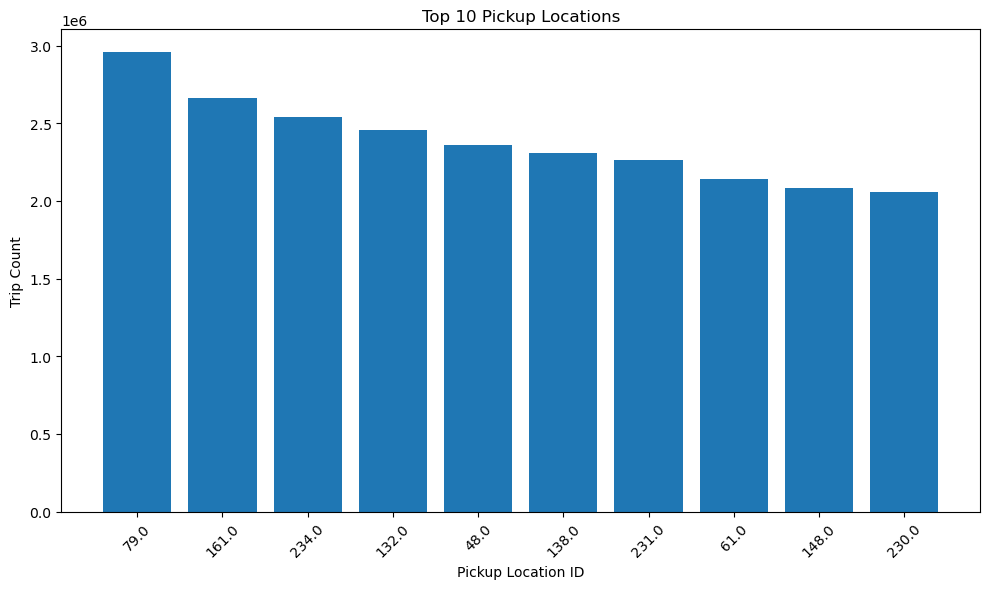

In [22]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

pickup_counts = (
    df.filter(col("PUlocationID").isNotNull())
      .groupBy("PUlocationID")
      .count()
      .orderBy("count", ascending=False)
      .limit(10)
      .toPandas()
)

plt.figure(figsize=(10, 6))
plt.bar(pickup_counts["PUlocationID"].astype(str), pickup_counts["count"])
plt.title("Top 10 Pickup Locations")
plt.xlabel("Pickup Location ID")
plt.ylabel("Trip Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## This bar chart shows the 10 pickup locations with the highest number of trips. After removing missing pickup location values, it highlights the busiest pickup areas in the dataset.


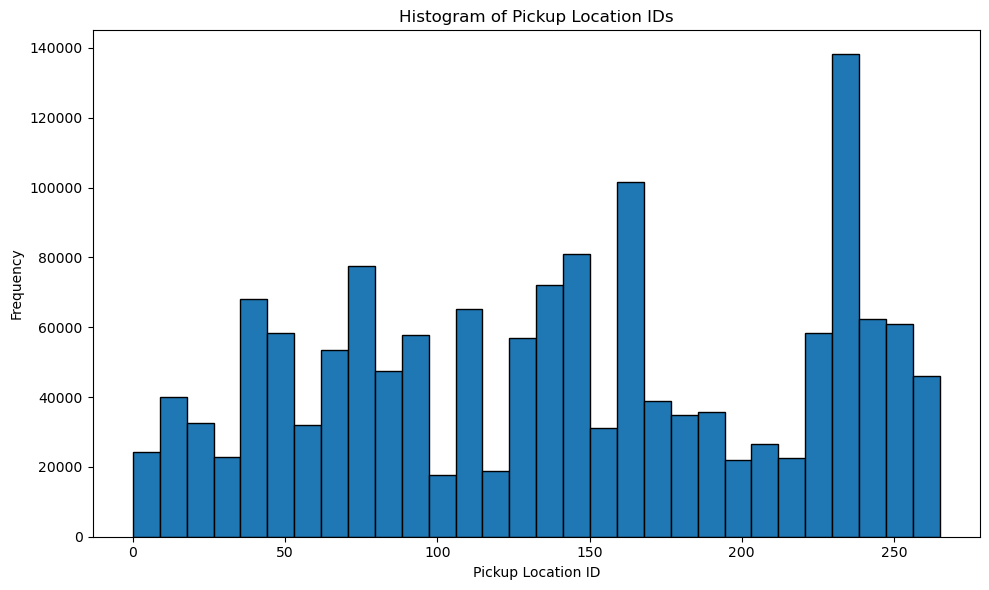

In [17]:
import matplotlib.pyplot as plt

pickup_sample = (
    df.select("PUlocationID")
      .dropna()
      .sample(False, 0.01, seed=42)
      .toPandas()
)

plt.figure(figsize=(10, 6))
plt.hist(pickup_sample["PUlocationID"], bins=30, edgecolor="black")
plt.title("Histogram of Pickup Location IDs")
plt.xlabel("Pickup Location ID")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## Histogram Explanation

This histogram shows the distribution of `PUlocationID` values in the dataset. Each bar represents a range of pickup location IDs, and the height of the bar shows how frequently values from that range appear in the sampled data. The plot helps visualize how pickup trips are distributed across different location identifiers.

The histogram suggests that some pickup location IDs occur much more frequently than others, since certain bars are noticeably taller than the rest. This indicates that taxi pickups are not evenly distributed across all locations, and some areas are much busier than others. Because `PUlocationID` is a location code rather than a continuous numerical measurement, this histogram should be interpreted as a frequency distribution of pickup categories rather than a true continuous variable distribution.

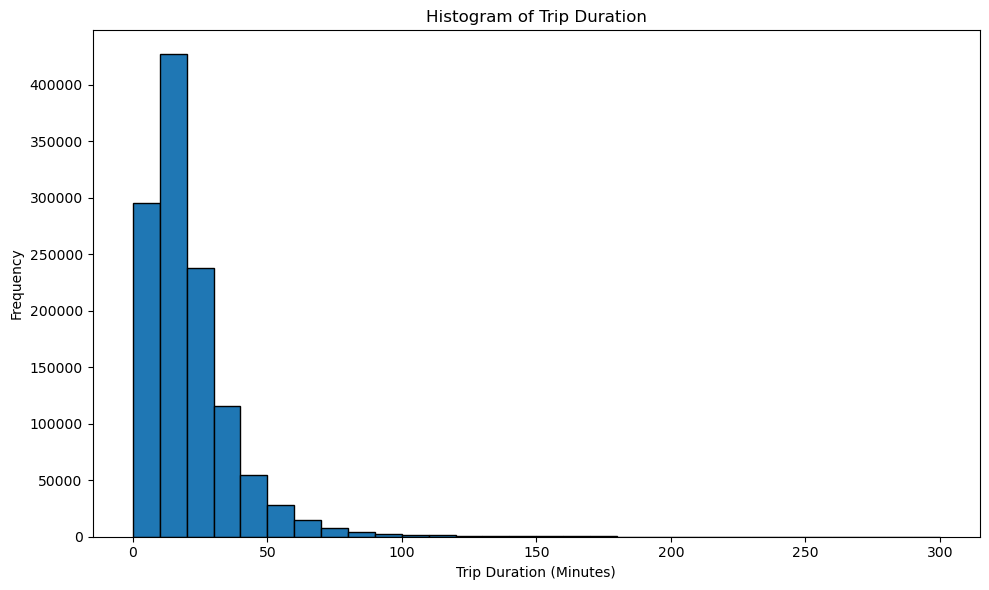

In [25]:
from pyspark.sql.functions import unix_timestamp, col
import matplotlib.pyplot as plt

duration_data = (
    df.select(
        ((unix_timestamp("dropOff_datetime") - unix_timestamp("pickup_datetime")) / 60).alias("trip_duration_minutes")
    )
    .dropna()
    .filter(col("trip_duration_minutes") > 0)
    .filter(col("trip_duration_minutes") < 300)
    .sample(False, 0.01, seed=42)
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.hist(duration_data["trip_duration_minutes"], bins=30, edgecolor="black")
plt.title("Histogram of Trip Duration")
plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



## This histogram shows the distribution of trip durations. It helps identify whether most trips are short, medium, or long, and whether outliers exist.


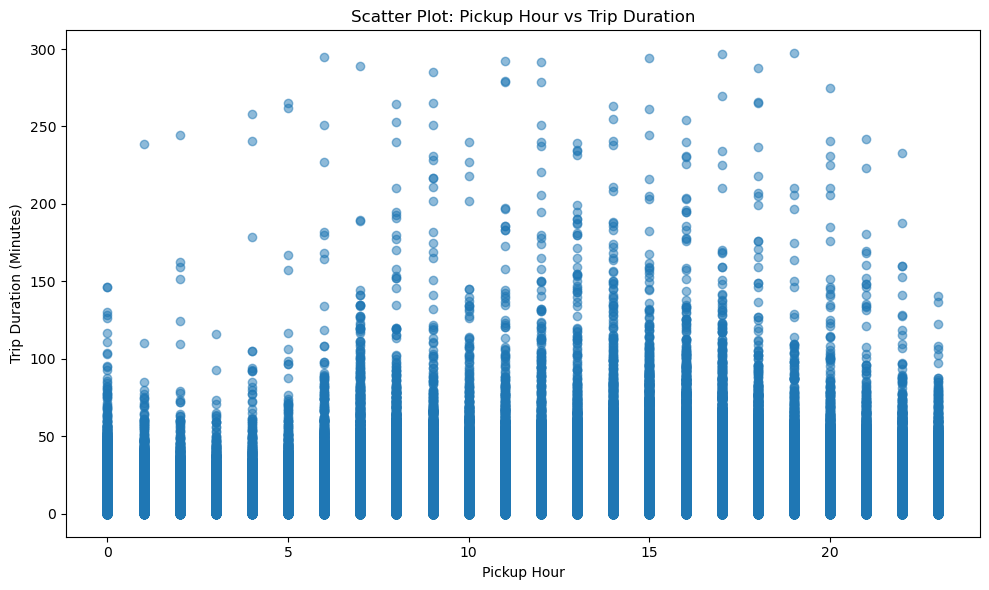

In [20]:
from pyspark.sql.functions import hour, unix_timestamp, col
import matplotlib.pyplot as plt

scatter_data = (
    df.select(
        hour("pickup_datetime").alias("pickup_hour"),
        ((unix_timestamp("dropOff_datetime") - unix_timestamp("pickup_datetime")) / 60).alias("trip_duration_minutes")
    )
    .dropna()
    .filter(col("trip_duration_minutes") > 0)
    .filter(col("trip_duration_minutes") < 300)
    .sample(False, 0.001, seed=42)
    .toPandas()
)

plt.figure(figsize=(10, 6))
plt.scatter(scatter_data["pickup_hour"], scatter_data["trip_duration_minutes"], alpha=0.5)
plt.title("Scatter Plot: Pickup Hour vs Trip Duration")
plt.xlabel("Pickup Hour")
plt.ylabel("Trip Duration (Minutes)")
plt.tight_layout()
plt.show()



## This scatter plot shows the relationship between pickup hour and trip duration. After removing invalid and extreme trip durations, the plot helps identify whether trips at certain hours tend to last longer.


## Preprocessing Plan

I will preprocess the NYC taxi dataset by first checking for missing values in important columns such as PUlocationID, DOlocationID, pickup_datetime, and dropOff_datetime. If missing values appear in essential columns, I would either remove those rows or fill them depending on how important the column is and how many values are missing. For categorical columns, I may replace missing values with a label such as "Unknown", while for numerical features created later, I may use summary-based filling methods if needed.

If data imbalance exists in the target variable, I will address it by examining the distribution of classes first. If some classes appear much more often than others, I may use undersampling, oversampling, or class weighting during model preparation so the model does not become biased toward the majority class. If the imbalance is small, I may keep the dataset as it is and simply note the limitation.

The main transformations I plan to apply include encoding categorical variables such as pickup and dropoff location IDs, extracting useful time-based features from pickup_datetime and dropOff_datetime, and creating a new feature such as trip duration. If numerical features are used in the final model, I may also scale them so that variables with larger ranges do not dominate the model. These steps will make the data more suitable for machine learning.

For preprocessing in Spark, I would use operations such as dropna(), fillna(), withColumn(), and filter() to clean and prepare the data. For categorical encoding and feature preparation, I would use Spark ML tools such as StringIndexer, OneHotEncoder, VectorAssembler, and possibly StandardScaler if scaling is needed.